# Вакцинация
Вакцинация в t=0, по 20 повторов для пяти долей восприимчивых.

Row,fraction,mean_peak,mean_cases,vaccinated,mean_I_T
,Float64,Float64,Float64,Float64,Float64
1,0.0,179.35,795.55,0.0,0.15
2,0.25,63.2,419.05,247.0,1.7
3,0.5,18.35,98.05,495.0,0.3
4,0.65,11.55,29.0,643.0,0.0
5,0.8,10.35,14.75,792.0,0.0


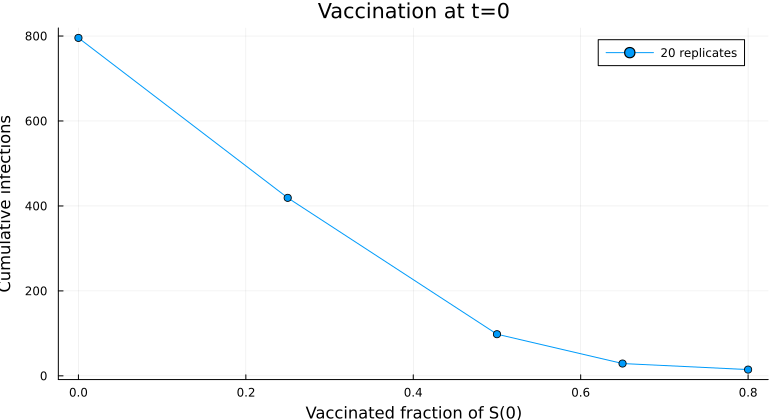

In [1]:
using DrWatson
@quickactivate "ContactEpidemics"
using ContactEpidemics.ContactProcesses
using ContactEpidemics.StudyTools
using DataFrames, CSV, Plots, Statistics


rows = NamedTuple[]
for fraction in [0.0,0.25,0.5,0.65,0.8]
    cfg = Settings(vaccination_time=0.0,vaccination_fraction=fraction)
    result = ensemble(cfg)
    for row in eachrow(result.metrics)
        push!(rows,(;fraction,NamedTuple(row)...))
    end
end
metrics = DataFrame(rows)
save_table("vaccination_runs",metrics)
summary = combine(groupby(metrics,:fraction),:peak=>mean=>:mean_peak,
    :cases=>mean=>:mean_cases,:vaccinated=>mean=>:vaccinated,
    :I_T=>mean=>:mean_I_T)
save_table("vaccination_summary",summary)
display(summary)
figure = plot(summary.fraction,summary.mean_cases,marker=:circle,
    xlabel="Vaccinated fraction of S(0)",ylabel="Cumulative infections",
    label="20 replicates",title="Vaccination at t=0")
savefig(figure,imagefile("vaccination"))
display(plot(figure; size=(780,420)))

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*